# Project - Part 2

In [1]:
import os
print("Current working directory:",os.getcwd())

import sys
sys.path.append('../../../../CppToPython')

import numpy as np
import GeDiM4Py as gedim

import matplotlib as mlt
import matplotlib.pyplot as plt
from matplotlib import cm

import time

import torch
import torch.nn as nn

# from IPython.display import clear_output
# from IPython.display import display, DisplayHandle

import libMOR
import importlib
importlib.reload(libMOR)

Current working directory: /content/workfolder/LOReduX/Project/Code


<module 'libMOR' from '/content/workfolder/LOReduX/Project/Code/libMOR.py'>

This part is code-wise essentially the same as Part_1 but with $g$ not affine anymore with respect to $\boldsymbol\mu$ as it's been explained in Part_0.

## POD solution

### Geometry setup

In [10]:
# Geometry definition
aMax  = 0.001 # Maximum FE area
L     = 1     # Squre domain length
order = 2     # Order of FE

In [11]:
[dofs, _, _] = libMOR.SetGeometry(aMax,L,order)
Nd = dofs.shape[1]
libMOR.AssembleAffineMatrix2()
[A, _] = libMOR.InnerProductMatrix()

### Snapshot matrix

In [12]:

M = 100 # Number of snapshots [potentially linearly dependent]

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

# Definition of the training set
trainSet = np.random.uniform(P[:,0],P[:,1],(M,P.shape[0]))

In [13]:
# Snapshot matrix creation
U = np.zeros((M,Nd))

# Cycles the row of training_set (M⨯2), that is
# all the random parameters generated before
for m in range(M):

	m0 = trainSet[m,0]
	m1 = trainSet[m,1]

	[snapshot, _] = libMOR.FOMSolF2(m0,m1)
	U[m,:] = np.copy(snapshot)

### Basis matrix

In [14]:
# Create the covariance matrix (An alternative is to use «VM, L, VMt = np.linalg.svd((C))»)
C = U@A@np.transpose(U) # Dimension M⨯M=(M⨯Nδ)⨯(Nδ⨯Nδ)⨯(Nδ⨯M)

# Eigenvalues and eigenvectors
[EigValM, EigVecM]  = np.linalg.eig(C)
EigValN = []
EigVecN = []

# Check which eigenvalues are real to numerical precision
# and then saves them, along with the respective eigenvectors
for e in range(len(EigValM)):

	eigR = EigValM[e].real # Real part of the eigenvalue
	eigC = EigValM[e].imag # Complex part of the eigenvalue

	assert np.isclose(eigC, 0.)
	# The assert statement works like an if structure but it's able to stop
	# the script if the condition is not satisfied by raising an expeption

	EigValN.append(eigR)
	EigVecN.append(EigVecM[e].real)

# Total sum of eigenvalues
totalEnergy = sum(EigValN)

# Cumulative sum of eigenvalues, that is it holds
# retained_energy_vector[1]=eigenvalues[1],
# retained_energy_vector[2]=eigenvalues[1]+eigenvalues[2],
# retained_energy_vector[3]=eigenvalues[1]+eigenvalues[2]+eigenvalues[3],
# and so on; the result is a vector dimensionally similar to eigenvalue
retainedEnergy = np.cumsum(EigValN)

# Relative cumulative sum of eigenvalues
relRetainedEnergy = retainedEnergy/totalEnergy

NewTol = 1. - 1e-7 # Number very close to 1, namely 0.9999999
N_max = 10
N = 0

# Checks which eigenvalues are necessary to have, once summed, a value greater than tol
for v in range(N_max):
	if relRetainedEnergy[v] <= NewTol:
		N += 1
	else:
		exit
# The function np.argmax «returns the indicies of the maximum
# values», so +1 is necessary since the indicies stars at 0

print("The reduced dimension is",N)

The reduced dimension is 9


In [15]:
# Create the basis function matrix
B = np.zeros((Nd,N))

for n in range(N):
	eigVec = EigVecN[n]

	basisVec = np.transpose(U)@eigVec
	normVec  = np.sqrt(np.transpose(basisVec)@A@basisVec)
	basisVec /= normVec

	B[:,n] = np.copy(basisVec)

	# «basis = (1/np.sqrt(snapshot_num))*np.transpose(snapshot_matrix)@eigenvector  (This is the one of the book!!)»
	# This is indeed the formula in lecture 4 (Ψₘ=(1/√λₘ)Σ_{k=1}^M[wₖ[αₘ]ₖ]) where «snapshot_num» is the eigenvalue
	# However the most important part is the eigenvector which can then be arbitraly scaled (with √λₘ or its norm)

libMOR.B = B # Copy by reference
libMOR.AssembleReducedAffineMatrix2()

### Speedup analysis

In [16]:
T = 100

absErr  = []
relErr  = []
speedUp = []

testSet = np.random.uniform(P[:, 0],P[:, 1],(T,P.shape[0]))

print("Computing error and speedup analysis")

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
    # Full Order Model (FOM)
    startFOM = time.time()
    [u_f, _]  = libMOR.FOMSolF2(m0,m1)
    timeFOM  = time.time() - startFOM

    # Reduced Order Model (ROM)
    startROM = time.time()
    [u_r, _]  = libMOR.ROMSolF2(m0,m1)
    timeROM  = time.time() - startROM
  
    # Speed up time
    speedUp.append(timeFOM/timeROM)
  
    # Absolute error calculations
    errFunction = u_f - u_r
    errNorm = np.sqrt(abs(np.transpose(errFunction)@A@errFunction))
    absErr.append(errNorm)
  
    # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("avarege relative error = ", np.mean(relErr) )
print("avarege absolute error = ", np.mean(absErr) )
print("avarege speed_up = ", np.mean(speedUp) )

Computing error and speedup analysis
avarege relative error =  0.0005842375343260313
avarege absolute error =  0.003701901319609084
avarege speed_up =  1.1358004854192254


## PINN solution

In [2]:
print(torch.__version__) # Checks Pytorch version

if torch.cuda.is_available(): # Checks if the GPU can be used
    print(torch.cuda.get_device_name(0)) # In my case "GeForce GTX 1650"
    device = torch.device("cuda")
else: # If available use the GPU otherwise use the CPU
    device = torch.device("cpu")

libMOR.device = device

2.7.0+cu118
NVIDIA GeForce GTX 1650


### Model setup

In [3]:
[nNI, nHL, nNH, nNO] = libMOR.SharedPINNStructure()
net = libMOR.PINN(nNI,nHL,nNH,nNO).to(device)
# net = libMOR.PINN(4,3,100,1).to(device)

In [4]:
libMOR.ff = libMOR.g2T
seed = 0 # Set a seed for random number generation for reproducibility sake
torch.manual_seed(seed) # Without it, it'd be random every time the code is run

MSELoss   = torch.nn.MSELoss() # Mean squared error loss function
optimiser = torch.optim.Adam(net.parameters()) # 1e-3=0.001 is the default learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser,factor=0.75,patience=5000)

### Mesh-free approach

In [5]:
# Data from Boundary Conditions (BC) which are datapoints for training
# In this case BC set u=0 in ∂Ω={(x,y)∈Ω=(0,1)² : x=0 ∨ y=0 ∨ x=1 ∨ y=1}
nBP = int(1e4) # Number of random boundary points
nIP = int(1e4) # Number of random internal points

onesBP  = libMOR.HomogenousTensor(nBP,1)
zerosBP = libMOR.HomogenousTensor(nBP,0)
zerosIP = libMOR.HomogenousTensor(nIP,0)
# Homogenous null tensor to evaluate the euclidian norm of the residual;
# indeed this is done by subtractig zero in the MSE loss function

In [6]:
# Training phase
l = 1 # Lambda to balance the losses

tol   = 1e-7
nEMax = int(5e5) # Number of maximum epochs
e     = 0
loss  = torch.tensor(1)

step   = int(1e2)
logger = libMOR.LoggerPINN(optimiser,step)

In [7]:
net.train()

while loss.item() >= tol and e <= nEMax: # and optimiser.param_groups[0]['lr']>1e-7
    optimiser.zero_grad() # Set the gradients to zero

    # BC Loss
    mseBC = libMOR.lossBC(net,MSELoss,nBP,zerosBP,onesBP)

    # PDE Loss
    mseRes = libMOR.lossRes(net,MSELoss,nIP,zerosIP)

    # Total loss
    [loss, l] = libMOR.lossTot(mseBC,mseRes,l)

    loss.backward()  # Backpropagation
    # if e > 1e4:
    #     torch.nn.utils.clip_grad_norm_(net.parameters(),max_norm=5e1)
    optimiser.step() # Optimiser update
    
    scheduler.step(loss.item()) # Scheduler check

    logger.log(e,step,mseBC,mseRes,loss,l,net)

    e += 1

0	meanL: 1.2050e+00	meanBC: 2.268263e-04	meanRes: 2.409563e+01	lr: 1e-05	λ: 0.01	Grad: 0.01
100	meanL: 9.8949e+01	meanBC: 4.615717e+00	meanRes: 1.891286e+03	lr: 1e-03	λ: 0.95	Grad: 20.07
200	meanL: 6.0259e+01	meanBC: 6.897900e+00	meanRes: 1.074124e+03	lr: 1e-03	λ: 0.95	Grad: 45.78
300	meanL: 2.0882e+01	meanBC: 7.087171e+00	meanRes: 2.829917e+02	lr: 1e-03	λ: 0.95	Grad: 38.94
400	meanL: 8.8988e+00	meanBC: 4.543041e+00	meanRes: 8.345385e+01	lr: 1e-03	λ: 0.94	Grad: 37.73
500	meanL: 7.7103e+00	meanBC: 4.585346e+00	meanRes: 2.847149e+01	lr: 1e-03	λ: 0.85	Grad: 184.07
600	meanL: 5.9504e+00	meanBC: 4.069021e+00	meanRes: 1.129559e+01	lr: 1e-03	λ: 0.73	Grad: 290.48
700	meanL: 4.3862e+00	meanBC: 3.523795e+00	meanRes: 5.857339e+00	lr: 1e-03	λ: 0.62	Grad: 317.07
800	meanL: 3.3618e+00	meanBC: 3.119065e+00	meanRes: 3.669690e+00	lr: 1e-03	λ: 0.54	Grad: 311.52
900	meanL: 2.7572e+00	meanBC: 2.808014e+00	meanRes: 2.730489e+00	lr: 1e-03	λ: 0.49	Grad: 336.70
1000	meanL: 2.2268e+00	meanBC: 2.574658e+00	mean

### PINN/FOM example

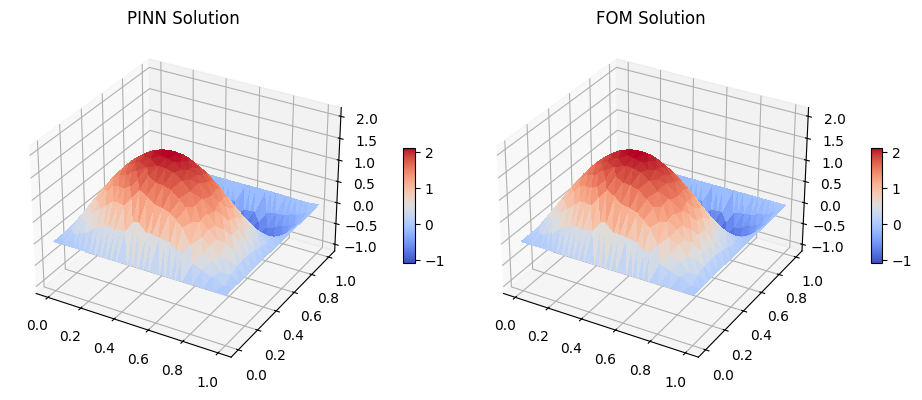

In [18]:
# Parameters
m0 = .45 # .75
m1 = .45 # .1

# Figure
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1,projection='3d')
ax2 = fig.add_subplot(1,2,2,projection='3d')
plt.subplots_adjust(wspace=0.01)

# Geometry
[dofs, strongs, mesh] = libMOR.SetGeometry(0.005,1,2)
x = np.concatenate((dofs[0,:],strongs[0,:]),axis=0)
y = np.concatenate((dofs[1,:],strongs[1,:]),axis=0)
triang = mlt.tri.Triangulation(x,y)


# PINN solution
[u, u_strong] = libMOR.buildSolPINN(net,m0,m1)
z = np.concatenate((u,u_strong), axis=0)

surf = ax1.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
fig.colorbar(surf,shrink=0.3,aspect=10,pad=0.1)
ax1.set_title("PINN Solution")


# FOM solution
libMOR.AssembleAffineMatrix1()
[u, u_strong] = libMOR.FOMSolF2(m0,m1)
z = np.concatenate((u,u_strong), axis=0)

surf = ax2.plot_trisurf(x,y,z,triangles=triang.triangles, \
                        cmap=cm.coolwarm,linewidth=0,antialiased=False)
fig.colorbar(surf,shrink=0.3,aspect=10,pad=0.1)
ax2.set_title("FOM Solution")


plt.show()


### Saving/Loading

In [ ]:
# Save the model
torch.save({
            'modelStateDict': net.state_dict(),
            'optimiserStateDict': optimiser.state_dict(),
            'schedulerStateDict': scheduler.state_dict(),
            'loss': loss.item(),
            'structure': [nNI,nHL,nNH,nNO],
            'lastLog': logger.last,
            },'PINN.pth')

In [5]:
# Load the model
PINN2 = torch.load('PINN2.pth')

net.load_state_dict(PINN2['modelStateDict'])
optimiser.load_state_dict(PINN2['optimiserStateDict'])
scheduler.load_state_dict(PINN2['schedulerStateDict'])
loss = torch.tensor(PINN2['loss'])

# The model has to be loaded after all the previous variables have
# been defined, that is before the for loop in the training phase

### Speedup analysis

In [8]:
# Geometry definition
aMax  = 0.001 # Maximum mesh area
L     = 1     # Squre domain length
order = 2     # Order of FE

libMOR.SetGeometry(aMax,L,order)
libMOR.AssembleAffineMatrix2()
[A, A_strong] = libMOR.InnerProductMatrix()

In [9]:
T = 100

absErr  = []
relErr  = []
speedUp = []

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

testSet = np.random.uniform(P[:, 0],P[:, 1],(T,P.shape[0]))

net.eval()

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
    # Full Order Model (FOM) solution
    startFOM = time.time()
    [u_f, u_strong] = libMOR.FOMSolF2(m0,m1)
    timeFOM  = time.time() - startFOM

    # Reduced Order Model (ROM) solution
    startROM = time.time()
    [u_n, u_strongn] = libMOR.buildSolPINN(net,m0,m1)
    timeROM  = time.time() - startROM
  
    # Speed up time
    speedUp.append(timeFOM/timeROM)
  
    # Absolute error calculations
    errFunctionDofs   = u_f - u_n
    errFunctionStrong = u_strong - u_strongn
    errNorm = np.sqrt(abs(np.transpose(errFunctionDofs)@A@errFunctionDofs) + \
                      abs(np.transpose(A_strong@errFunctionStrong)@A@A_strong@errFunctionStrong))
    absErr.append(errNorm)
  
    # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("Avarege relative error:\t",np.mean(relErr))
print("Avarege absolute error:\t",np.mean(absErr))
print("Avarege speedup:\t",np.mean(speedUp))

Avarege relative error:	 0.025801172012424364
Avarege absolute error:	 0.1632775870679217
Avarege speedup:	 90.05315222018473


## POD-NN solution

### POD section

In [2]:
# Geometry definition
aMax  = 0.001 # Maximum mesh area
L     = 1     # Squre domain length
order = 2     # Order of FE

In [3]:
[dofs, strongs, mesh] = libMOR.SetGeometry(aMax,L,order)
Nd = dofs.shape[1]
libMOR.AssembleAffineMatrix2()
[A, _] = libMOR.InnerProductMatrix()

In [4]:

M = int(1e3) # Number of snapshots [potentially linearly dependent]

# Lists containing two numbers
m0R = [0.1,1] # μ₀ range
m1R = [0.1,1] # μ₁ range

# 2⨯2 Matrix created by the previous two lists
P = np.array([m0R,m1R])

# Definition of the training set
trainSet = np.random.uniform(P[:,0],P[:,1],(M,P.shape[0]))

In [5]:
# Snapshot matrix creation
U = np.zeros((M,Nd))

# Cycles the row of training_set (M⨯2), that is
# all the random parameters generated before
for m in range(M):

	m0 = trainSet[m,0]
	m1 = trainSet[m,1]

	[snapshot, _] = libMOR.FOMSolF2(m0,m1)
	U[m,:] = np.copy(snapshot)

In [6]:
# Create the covariance matrix (An alternative is to use «VM, L, VMt = np.linalg.svd((C))»)
C = U@A@np.transpose(U) # Dimension M⨯M=(M⨯Nδ)⨯(Nδ⨯Nδ)⨯(Nδ⨯M)

# Eigenvalues and eigenvectors
[EigValM, EigVecM]  = np.linalg.eig(C)
EigValN = []
EigVecN = []

# Check which eigenvalues are real to numerical precision
# and then saves them, along with the respective eigenvectors
for e in range(len(EigValM)):

	eigR = EigValM[e].real # Real part of the eigenvalue
	eigC = EigValM[e].imag # Complex part of the eigenvalue

	assert np.isclose(eigC, 0.)
	# The assert statement works like an if structure but it's able to stop
	# the script if the condition is not satisfied by raising an expeption

	EigValN.append(eigR)
	EigVecN.append(EigVecM[e].real)

# Total sum of eigenvalues
totalEnergy = sum(EigValN)

# Cumulative sum of eigenvalues, that is it holds
# retained_energy_vector[1]=eigenvalues[1],
# retained_energy_vector[2]=eigenvalues[1]+eigenvalues[2],
# retained_energy_vector[3]=eigenvalues[1]+eigenvalues[2]+eigenvalues[3],
# and so on; the result is a vector dimensionally similar to eigenvalue
retainedEnergy = np.cumsum(EigValN)

# Relative cumulative sum of eigenvalues
relRetainedEnergy = retainedEnergy/totalEnergy

NewTol = 1. - 1e-7 # Number very close to 1, namely 0.9999999
N_max = 10
N = 0

# Checks which eigenvalues are necessary to have, once summed, a value greater than tol
for v in range(N_max):
	if relRetainedEnergy[v] <= NewTol:
		N += 1
	else:
		exit
# The function np.argmax «returns the indicies of the maximum
# values», so +1 is necessary since the indicies stars at 0

print("The reduced dimension is ",N)

The reduced dimension is  9


In [7]:
# Create the basis function matrix
B = np.zeros((Nd,N))

for n in range(N):
	eigVec = EigVecN[n]

	basisVec = np.transpose(U)@eigVec
	normVec  = np.sqrt(np.transpose(basisVec)@A@basisVec)
	basisVec /= normVec

	B[:,n] = np.copy(basisVec)

	# «basis = (1/np.sqrt(snapshot_num))*np.transpose(snapshot_matrix)@eigenvector  (This is the one of the book!!)»
	# This is indeed the formula in lecture 4 (Ψₘ=(1/√λₘ)Σ_{k=1}^M[wₖ[αₘ]ₖ]) where «snapshot_num» is the eigenvalue
	# However the most important part is the eigenvector which can then be arbitraly scaled (with √λₘ or its norm)

libMOR.B = B # Copy by reference
libMOR.AssembleReducedAffineMatrix2()

### NN section

In [8]:
print(torch.__version__) # Checks Pytorch version

if torch.cuda.is_available(): # Checks if the GPU can be used
    print(torch.cuda.get_device_name(0)) # In my case "GeForce GTX 1650"
    device = torch.device("cuda")
else: # If available use the GPU otherwise use the CPU
    device = torch.device("cpu")

libMOR.device = device

2.7.0+cu118
NVIDIA GeForce GTX 1650


In [9]:
[nNI, nHL, nNH, nNO] = libMOR.SharedPODNNStructure(N)
net = libMOR.PODNN(nNI,nHL,nNH,nNO).to(device)
# torch.set_default_dtype(torch.float32)

In [10]:
seed = 31
torch.manual_seed(seed)

MSELoss   = nn.MSELoss()
optimiser = torch.optim.Adam(net.parameters(),lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser,factor=0.75,patience=100)

In [11]:
# Training set
An = np.transpose(B)@A@B

outputRef = []

for i in range(U.shape[0]):
  
    snapshot = U[i]

    snapshotP = np.linalg.solve(An,np.transpose(B)@A@snapshot)
  
    outputRef.append(snapshotP)

outputRef = np.array(outputRef)
outputRef = torch.from_numpy(outputRef).float().to(device)

m0 = torch.from_numpy(trainSet[:,0].reshape(-1,1)).float().to(device)
m1 = torch.from_numpy(trainSet[:,1].reshape(-1,1)).float().to(device)

In [12]:
tol   = 1e-6
nEMax = int(5e5)  # Number of maximum epochs
e     = 0

loss   = torch.tensor(1)
step   = int(1e2)
logger = libMOR.LoggerPODNN(optimiser,step)

In [13]:
net.train()

while loss.item() >= tol and e <= nEMax:
    optimiser.zero_grad() # Set the gradients to zero
            
    outputNet = net(m0,m1) # Compute network output
    
    loss = MSELoss(outputNet,outputRef)

    loss.backward()  # Backpropagation
    optimiser.step() # Optimiser update

    logger.log(e,step,loss,net)

    e += 1

0	meanL: 2.7579e-01	lr: 1e-06	Grad: 0.01
100	meanL: 2.7295e+01	lr: 1e-04	Grad: 1.16
200	meanL: 2.6125e+01	lr: 1e-04	Grad: 1.86
300	meanL: 2.3060e+01	lr: 1e-04	Grad: 3.61
400	meanL: 2.1157e+01	lr: 1e-04	Grad: 3.16
500	meanL: 1.9466e+01	lr: 1e-04	Grad: 3.20
600	meanL: 1.8171e+01	lr: 1e-04	Grad: 3.08
700	meanL: 1.7421e+01	lr: 1e-04	Grad: 2.73
800	meanL: 1.6916e+01	lr: 1e-04	Grad: 2.40
900	meanL: 1.6497e+01	lr: 1e-04	Grad: 2.15
1000	meanL: 1.6024e+01	lr: 1e-04	Grad: 2.02
1100	meanL: 1.5361e+01	lr: 1e-04	Grad: 2.00
1200	meanL: 1.4707e+01	lr: 1e-04	Grad: 1.99
1300	meanL: 1.3849e+01	lr: 1e-04	Grad: 2.32
1400	meanL: 1.2926e+01	lr: 1e-04	Grad: 2.25
1500	meanL: 1.2435e+01	lr: 1e-04	Grad: 2.09
1600	meanL: 1.1997e+01	lr: 1e-04	Grad: 2.04
1700	meanL: 1.1573e+01	lr: 1e-04	Grad: 2.00
1800	meanL: 1.1173e+01	lr: 1e-04	Grad: 1.97
1900	meanL: 1.0803e+01	lr: 1e-04	Grad: 1.93
2000	meanL: 1.0459e+01	lr: 1e-04	Grad: 1.89
2100	meanL: 1.0121e+01	lr: 1e-04	Grad: 1.86
2200	meanL: 9.7692e+00	lr: 1e-04	Grad: 1.85


### POD-NN/FOM example

In [14]:
m0 = .45
m1 = .45

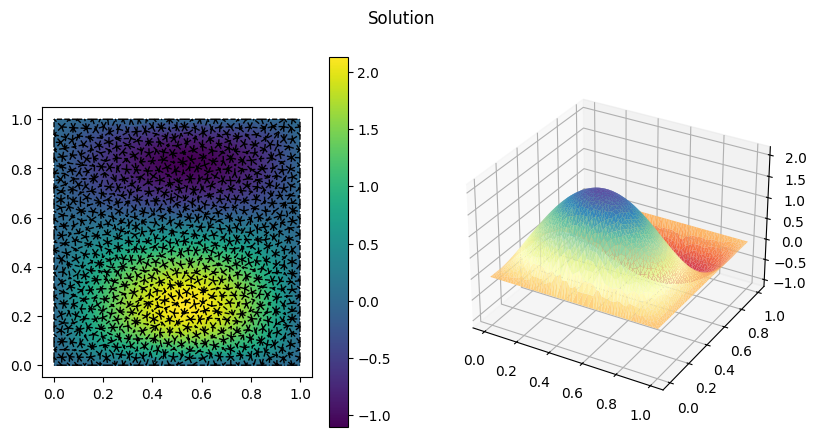

In [15]:
# Full solution
[FOMSol, FOMSolStrong] = libMOR.FOMSolF2(m0,m1)
gedim.PlotSolution(mesh,dofs,strongs,FOMSol,FOMSolStrong)

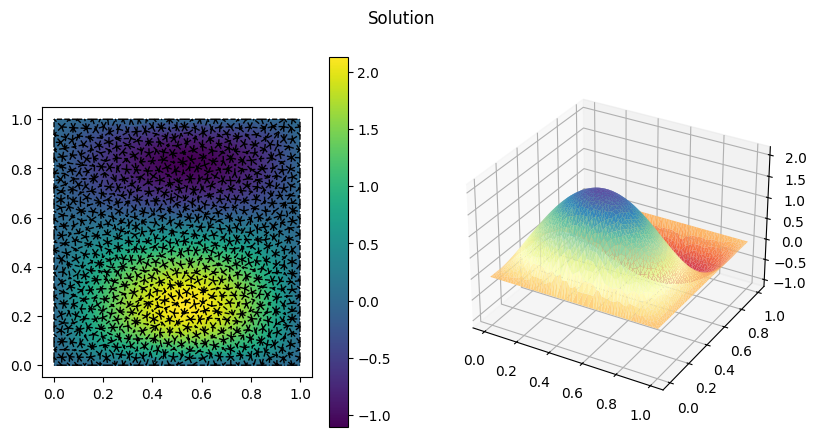

In [16]:
# Reduced solution
ROMsolN = libMOR.buildSolPODNN(net,m0,m1)
ROMSol = B@ROMsolN
gedim.PlotSolution(mesh,dofs,strongs,ROMSol,FOMSolStrong)

### Speedup Analysis

In [17]:
T = 100

absErr  = []
relErr  = []
speedUp = []

testSet = np.random.uniform(P[:, 0],P[:, 1],(T, P.shape[0]))

net.eval()

for t in range(T):

    m0 = testSet[t,0]
    m1 = testSet[t,1]
    
        # Full Order Model (FOM) solution
    startFOM = time.time()
    [u_f, _] = libMOR.FOMSolF2(m0,m1)
    timeFOM  = time.time() - startFOM

        # Reduced Order Model (ROM) solution
    startROM = time.time()
    u_r = libMOR.buildSolPODNN(net,m0,m1)
    u_n = B@u_r
    timeROM  = time.time() - startROM
  
        # Speed up time
    speedUp.append(timeFOM/timeROM)
  
        # Absolute error calculations
    errFunction = u_f - u_n
    errNorm = np.sqrt(abs(np.transpose(errFunction)@A@errFunction))
    absErr.append(errNorm)
  
        # Relative error calculations
    FOMNorm = np.sqrt(abs(np.transpose(u_f)@A@u_f))
    errRel  = errNorm/FOMNorm
    relErr.append(errRel)
  
print("avarege relative error = ", np.mean(relErr) )
print("avarege absolute error = ", np.mean(absErr) )
print("avarege speed_up = ", np.mean(speedUp) )

avarege relative error =  0.0016212004028320181
avarege absolute error =  0.009659860116681226
avarege speed_up =  408.7783581813445
